# INSTITUTO FEDERAL DO NORTE DE MINAS GERAIS - Campus Montes Claros
**Disciplina:** Processamento Digital de Imagens  
**Tema:** Atividade Prática 2b - Filtragem Espacial  
**Professor:** Wagner Ferreira de Barros  
**Data:** 03/05/2026  
**Integrantes:** Gabriel Davi Mota Baia e Lucas Santos Ribeiro

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para exibir imagens lado a lado
def plot_images(images, titles, columns=2):
    n = len(images)
    rows = (n + columns - 1) // columns
    plt.figure(figsize=(15, 5 * rows))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, columns, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Carregar a imagem enviada: image-cinza-lago.jpg
img_original = cv2.imread('image-cinza-lago.jpg', cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("ERRO: Certifique-se de que o arquivo 'image-cinza-lago.jpg' está na mesma pasta.)")

Questão 1 - Suavização por Média

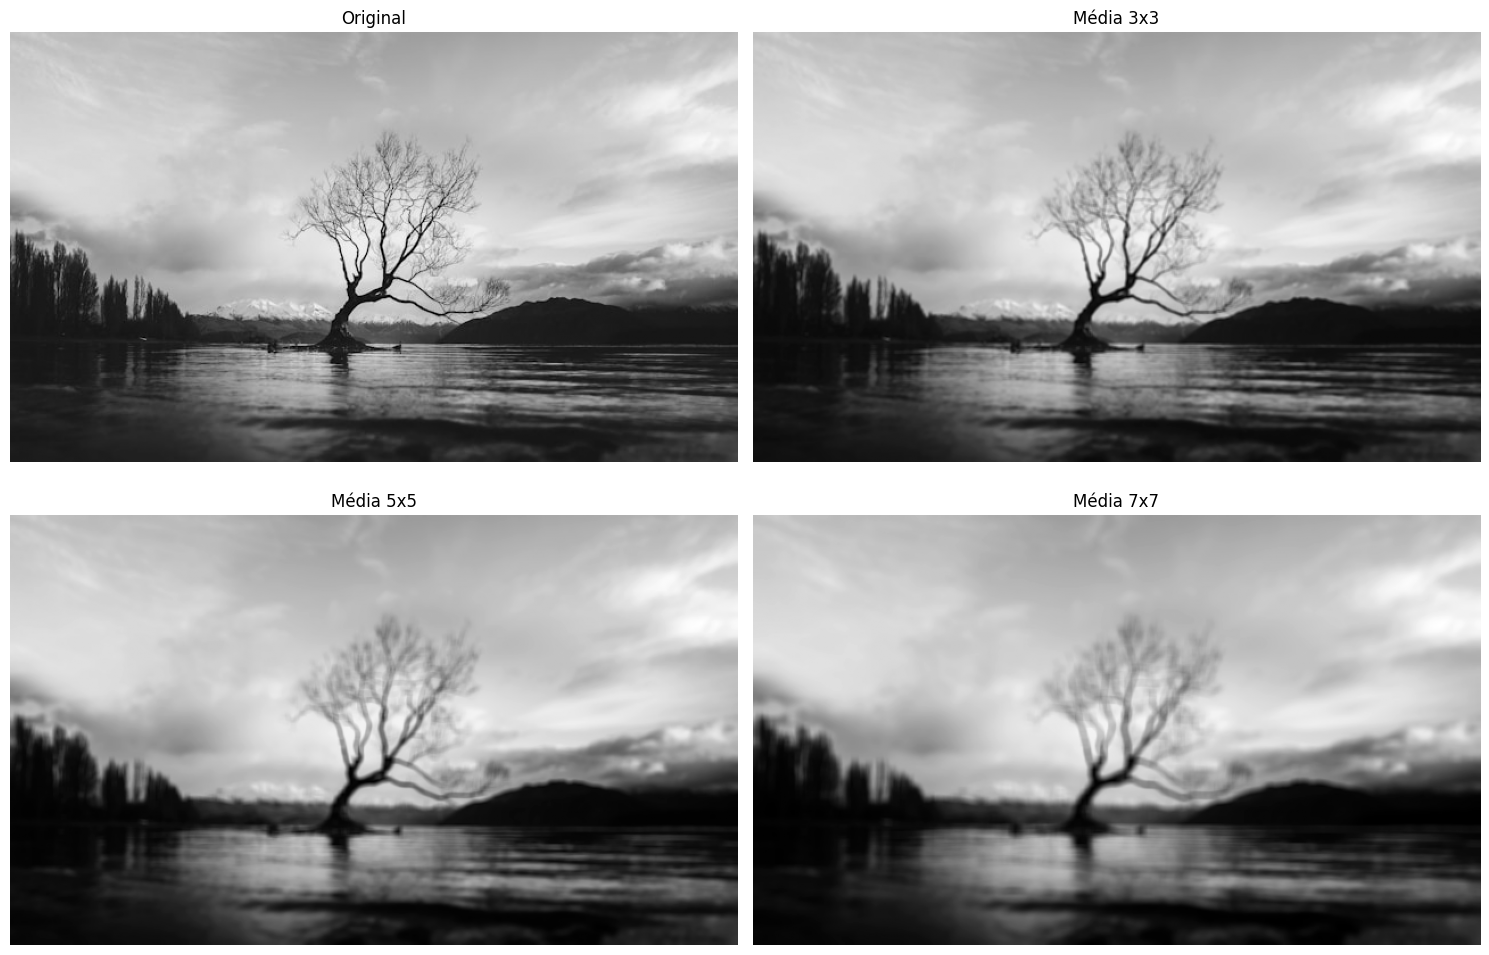

In [17]:
# Aplicando filtros de média com kernels 3x3, 5x5 e 7x7
blur_3x3 = cv2.blur(img_original, (3, 3))
blur_5x5 = cv2.blur(img_original, (5, 5))
blur_7x7 = cv2.blur(img_original, (7, 7))

# Exibição
q1_images = [img_original, blur_3x3, blur_5x5, blur_7x7]
q1_titles = ['Original', 'Média 3x3', 'Média 5x5', 'Média 7x7']
plot_images(q1_images, q1_titles)

Questão 2 - Ruído Sal e Pimenta e Mediana

In [ ]:
def add_sp_noise(image, amount=0.04):
    noisy = np.copy(image)
    # Sal
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255
    # Pimenta
    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

def calculate_psnr(orig, proc):
    mse = np.mean((orig - proc) ** 2)
    if mse == 0: return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Implementação
img_noisy = add_sp_noise(img_original, 0.05)
median_3x3 = cv2.medianBlur(img_noisy, 3)
median_5x5 = cv2.medianBlur(img_noisy, 5)

# Métricas
psnr_noisy = calculate_psnr(img_original, img_noisy)
psnr_m3 = calculate_psnr(img_original, median_3x3)
psnr_m5 = calculate_psnr(img_original, median_5x5)

plot_images([img_noisy, median_3x3, median_5x5], 
            [f'Ruidosa ({psnr_noisy:.2f}dB)', f'Mediana 3x3 ({psnr_m3:.2f}dB)', f'Mediana 5x5 ({psnr_m5:.2f}dB)'])

Questão 3 - Combinação de Filtros (Cascata)

In [ ]:
# Caso 1: Média -> Mediana
case1 = cv2.medianBlur(cv2.blur(img_noisy, (5, 5)), 5)
# Caso 2: Mediana -> Média
case2 = cv2.blur(cv2.medianBlur(img_noisy, 5), (5, 5))

plot_images([img_noisy, case1, case2], ['Original Ruidosa', 'Média -> Mediana', 'Mediana -> Média'])